# Subtask 2 Factor Statistics and Simple Classifier

This notebook focuses only on Subtask 2: suicide-related factor identification.

It includes:

1. Setup and factor parsing
2. Label statistics
3. Label statistics by suicide-risk category
4. Simple non-deep-learning classifier
5. Validation results and error inspection

## 1. Setup

Load `train.xlsx`, normalize risk labels, parse the `factors` column, and deduplicate factor labels within each post.

In [1]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support
from sklearn.model_selection import GroupShuffleSplit
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer

pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("train.xlsx")
REPORT_DIR = Path("reports")
REPORT_DIR.mkdir(exist_ok=True)

RISK_ORDER = ["Indicator", "Ideation", "Behavior", "Attempt"]
RISK_LABEL_MAP = {
    "indicator": "Indicator",
    "ideation": "Ideation",
    "behavior": "Behavior",
    "attempt": "Attempt",
}

FACTOR_LABELS = [
    "mental health issues",
    "physical health/characteristic",
    "substance use",
    "hopelessness",
    "emotion dysregulation",
    "low self-esteem",
    "poor school performance",
    "low socio-economic status",
    "interpersonal violence",
    "prior self-harm or suicidal thought/attempt",
    "poor social support",
    "interpersonal difficulty",
    "dysfunctional family",
    "exposure to others' suicide",
    "stressful life event",
    "traumatic experience",
    "cognitive deficits",
    "suicide means (with access)",
    "sexual orientation related issues",
    "social support",
    "coping strategy",
    "psychological capital",
    "sense of responsibility",
    "meaning in life",
]


def normalize_risk_label(value):
    return RISK_LABEL_MAP.get(str(value).strip().lower(), np.nan)


def parse_factor_list(value):
    if pd.isna(value):
        return []
    parsed = ast.literal_eval(value) if isinstance(value, str) else value
    labels = [str(label).strip() for label in parsed if str(label).strip()]
    return sorted(set(labels))


df = pd.read_excel(DATA_PATH)
df = df.rename(columns={"suicide risk": "risk_level"}).copy()
df["risk_level"] = df["risk_level"].apply(normalize_risk_label)
df["post"] = df["post"].fillna("")
df["factor_labels"] = df["factors"].apply(parse_factor_list)
df["factor_count"] = df["factor_labels"].apply(len)

unknown_labels = sorted(set().union(*df["factor_labels"]) - set(FACTOR_LABELS))
missing_taxonomy_labels = sorted(set(FACTOR_LABELS) - set().union(*df["factor_labels"]))

print(f"Loaded {len(df):,} rows")
print(f"Unknown labels in data: {unknown_labels}")
print(f"Taxonomy labels absent from training data: {missing_taxonomy_labels}")
display(df[["row_id", "risk_level", "post", "factor_labels", "factor_count"]].head())

Loaded 1,635 rows
Unknown labels in data: []
Taxonomy labels absent from training data: []


,row_id,risk_level,post,factor_labels,factor_count
0,P00000,Ideation,"My thoughts are getting worse. Already am suffering from severe depression due to past events over the months, finally got into therapy....","[coping strategy, dysfunctional family, emotion dysregulation, hopelessness, mental health issues, poor social support, prior self-harm ...",10
1,P00001,Ideation,"I'm done with this healing and everything.. I'm done..I tried a lot. I cannot do this anymore. I'm going to die, goodbye.","[coping strategy, hopelessness]",2
2,P00002,Ideation,"Tired. 12:34am at night. 6% charge on my phone. World is quiet, world is dark. I just want to pass away in my sleep. I do not want to wa...",[hopelessness],1
3,P00003,Ideation,"Screw this life. Someone give me more reasons to kill myself, because that's what people on the internet did anyway when I sought for he...","[coping strategy, emotion dysregulation, interpersonal violence, poor social support]",4
4,P00004,Ideation,Is getting admitted to the hospital fine? I do not want to see anyone anymore. I do not care if my friends think I'm dead.. I wanna die ...,"[coping strategy, emotion dysregulation, interpersonal difficulty, low self-esteem, psychological capital]",5


## 2. Labels Statistics

Count how often each factor label appears in the training set. Labels are deduplicated within each post before counting.

,factor,post_count,post_percent
3,hopelessness,745,45.57
4,emotion dysregulation,542,33.15
10,poor social support,501,30.64
5,low self-esteem,475,29.05
20,coping strategy,443,27.09
17,suicide means (with access),292,17.86
21,psychological capital,238,14.56
0,mental health issues,228,13.94
9,prior self-harm or suicidal thought/attempt,215,13.15
11,interpersonal difficulty,195,11.93


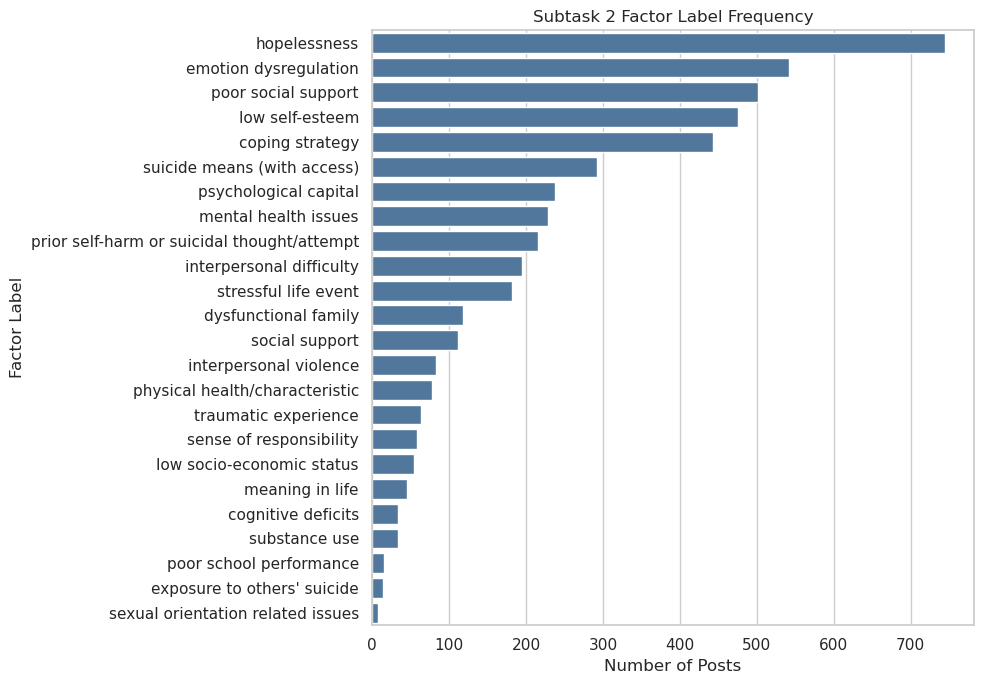

In [2]:
mlb = MultiLabelBinarizer(classes=FACTOR_LABELS)
Y = mlb.fit_transform(df["factor_labels"])

label_stats = pd.DataFrame(
    {
        "factor": mlb.classes_,
        "post_count": Y.sum(axis=0),
        "post_percent": Y.mean(axis=0) * 100,
    }
).sort_values("post_count", ascending=False)

label_stats["post_percent"] = label_stats["post_percent"].round(2)
label_stats.to_csv(REPORT_DIR / "subtask2_factor_label_stats.csv", index=False)

display(label_stats)

plt.figure(figsize=(10, 7))
sns.barplot(data=label_stats, y="factor", x="post_count", color="#4477AA")
plt.title("Subtask 2 Factor Label Frequency")
plt.xlabel("Number of Posts")
plt.ylabel("Factor Label")
plt.tight_layout()
plt.show()

## 3. Number of Factor Labels per Post

Analyze how many factor labels each post has on average.

,post_count,average_labels_per_post,median_labels_per_post,min_labels_per_post,max_labels_per_post
Whole,1635.0,2.92,2.0,0.0,18.0
Indicator,611.0,2.40,2.0,0.0,9.0
Ideation,519.0,2.87,2.0,0.0,14.0
Behavior,391.0,3.27,2.0,0.0,18.0
Attempt,114.0,4.72,4.0,0.0,17.0


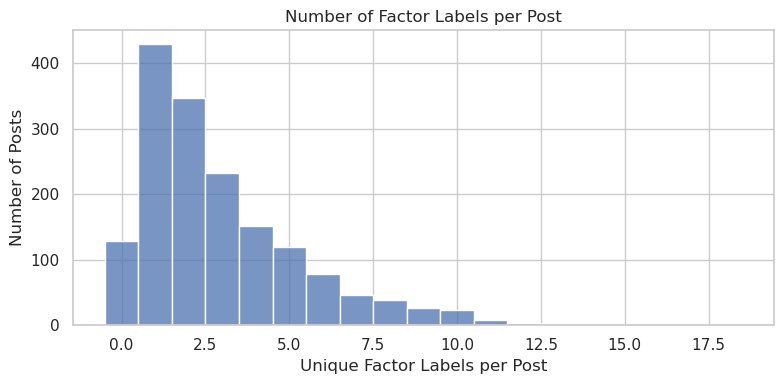

In [3]:
factor_count_stats = df["factor_count"].agg(
    post_count="count",
    average_labels_per_post="mean",
    median_labels_per_post="median",
    min_labels_per_post="min",
    max_labels_per_post="max",
)

factor_count_by_risk = df.groupby("risk_level")["factor_count"].agg(
    post_count="count",
    average_labels_per_post="mean",
    median_labels_per_post="median",
    min_labels_per_post="min",
    max_labels_per_post="max",
).reindex(RISK_ORDER)

factor_count_summary = pd.concat(
    [pd.DataFrame([factor_count_stats], index=["Whole"]), factor_count_by_risk]
).round(2)
factor_count_summary.to_csv(REPORT_DIR / "subtask2_factor_count_per_post_stats.csv")

display(factor_count_summary)

plt.figure(figsize=(8, 4))
sns.histplot(df["factor_count"], bins=range(0, int(df["factor_count"].max()) + 2), discrete=True)
plt.title("Number of Factor Labels per Post")
plt.xlabel("Unique Factor Labels per Post")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

## 4. Label Statistics by Risk Level

Compare which factors appear most often within each suicide-risk category.

,mental health issues,physical health/characteristic,substance use,hopelessness,emotion dysregulation,low self-esteem,poor school performance,low socio-economic status,interpersonal violence,prior self-harm or suicidal thought/attempt,...,stressful life event,traumatic experience,cognitive deficits,suicide means (with access),sexual orientation related issues,social support,coping strategy,psychological capital,sense of responsibility,meaning in life
risk_level,,,,,,,,,,,,,,,,,,,,,
Indicator,63,19,9,223,197,147,6,16,27,9,...,51,17,9,2,3,37,191,105,8,18
Ideation,81,25,14,275,175,194,6,21,29,40,...,57,16,13,25,1,30,121,63,21,13
Behavior,54,25,8,188,125,99,3,16,15,65,...,52,17,8,226,2,34,90,47,18,7
Attempt,30,9,2,59,45,35,1,1,12,101,...,22,14,3,39,2,11,41,23,11,7


,mental health issues,physical health/characteristic,substance use,hopelessness,emotion dysregulation,low self-esteem,poor school performance,low socio-economic status,interpersonal violence,prior self-harm or suicidal thought/attempt,...,stressful life event,traumatic experience,cognitive deficits,suicide means (with access),sexual orientation related issues,social support,coping strategy,psychological capital,sense of responsibility,meaning in life
risk_level,,,,,,,,,,,,,,,,,,,,,
Indicator,10.31,3.11,1.47,36.50,32.24,24.06,0.98,2.62,4.42,1.47,...,8.35,2.78,1.47,0.33,0.49,6.06,31.26,17.18,1.31,2.95
Ideation,15.61,4.82,2.70,52.99,33.72,37.38,1.16,4.05,5.59,7.71,...,10.98,3.08,2.50,4.82,0.19,5.78,23.31,12.14,4.05,2.50
Behavior,13.81,6.39,2.05,48.08,31.97,25.32,0.77,4.09,3.84,16.62,...,13.30,4.35,2.05,57.80,0.51,8.70,23.02,12.02,4.60,1.79
Attempt,26.32,7.89,1.75,51.75,39.47,30.70,0.88,0.88,10.53,88.60,...,19.30,12.28,2.63,34.21,1.75,9.65,35.96,20.18,9.65,6.14


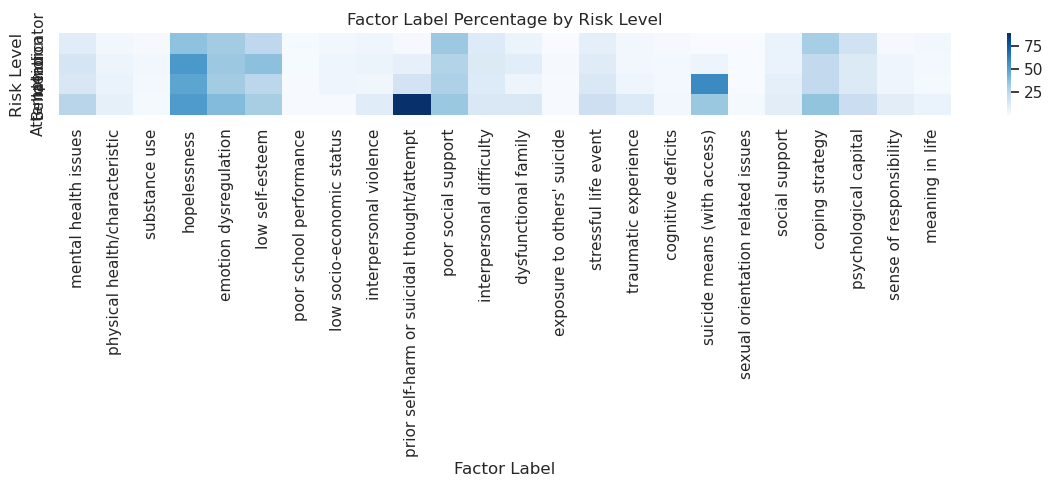

In [4]:
label_matrix = pd.DataFrame(Y, columns=mlb.classes_)
label_matrix["risk_level"] = df["risk_level"].values

label_by_risk_count = label_matrix.groupby("risk_level")[mlb.classes_].sum().reindex(RISK_ORDER)
label_by_risk_percent = label_matrix.groupby("risk_level")[mlb.classes_].mean().reindex(RISK_ORDER) * 100

label_by_risk_count.to_csv(REPORT_DIR / "subtask2_factor_by_risk_count.csv")
label_by_risk_percent.round(2).to_csv(REPORT_DIR / "subtask2_factor_by_risk_percent.csv")

display(label_by_risk_count)
display(label_by_risk_percent.round(2))

plt.figure(figsize=(12, 5))
sns.heatmap(label_by_risk_percent, cmap="Blues", annot=False)
plt.title("Factor Label Percentage by Risk Level")
plt.xlabel("Factor Label")
plt.ylabel("Risk Level")
plt.tight_layout()
plt.show()

## 5. Simple Classifier: TF-IDF + Logistic Regression

Train a simple non-deep-learning multi-label classifier. The split is grouped by `anon_user_id` so posts from the same author do not appear in both training and validation.

In [5]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, valid_idx = next(splitter.split(df, groups=df["anon_user_id"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
valid_df = df.iloc[valid_idx].reset_index(drop=True)

Y_train = mlb.transform(train_df["factor_labels"])
Y_valid = mlb.transform(valid_df["factor_labels"])

classifier = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                strip_accents="unicode",
            ),
        ),
        (
            "clf",
            OneVsRestClassifier(
                LogisticRegression(
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=42,
                )
            ),
        ),
    ]
)

classifier.fit(train_df["post"], Y_train)
Y_pred = classifier.predict(valid_df["post"])

print(f"Train rows: {len(train_df):,}")
print(f"Validation rows: {len(valid_df):,}")
print(f"Shared users across split: {set(train_df['anon_user_id']) & set(valid_df['anon_user_id'])}")

Train rows: 1,255
Validation rows: 380
Shared users across split: set()


## 6. Validation Results

Macro F1 is the official style of metric for Subtask 2, because each factor category matters equally.

In [6]:
macro_f1 = f1_score(Y_valid, Y_pred, average="macro", zero_division=0)
micro_f1 = f1_score(Y_valid, Y_pred, average="micro", zero_division=0)
samples_f1 = f1_score(Y_valid, Y_pred, average="samples", zero_division=0)

print(f"Macro F1:   {macro_f1:.4f}")
print(f"Micro F1:   {micro_f1:.4f}")
print(f"Samples F1: {samples_f1:.4f}")

precision, recall, f1, support = precision_recall_fscore_support(
    Y_valid,
    Y_pred,
    average=None,
    zero_division=0,
)

per_label_results = pd.DataFrame(
    {
        "factor": mlb.classes_,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
        "predicted_count": Y_pred.sum(axis=0),
    }
).sort_values("f1", ascending=True)

per_label_results.to_csv(REPORT_DIR / "subtask2_simple_classifier_per_label_results.csv", index=False)
display(per_label_results.round(3))

Macro F1:   0.3774
Micro F1:   0.6024
Samples F1: 0.4734


,factor,precision,recall,f1,support,predicted_count
2,substance use,0.000,0.000,0.000,3,0
18,sexual orientation related issues,0.000,0.000,0.000,1,0
16,cognitive deficits,0.000,0.000,0.000,6,0
6,poor school performance,0.000,0.000,0.000,1,0
13,exposure to others' suicide,0.000,0.000,0.000,3,0
15,traumatic experience,0.500,0.043,0.080,23,2
22,sense of responsibility,0.077,0.143,0.100,7,13
23,meaning in life,0.500,0.125,0.200,8,2
1,physical health/characteristic,0.167,0.286,0.211,7,12
7,low socio-economic status,1.000,0.167,0.286,12,2


## 7. Error Inspection

Look at examples where the simple classifier misses or adds factor labels.

In [7]:
valid_predictions = valid_df[["row_id", "risk_level", "post", "factor_labels"]].copy()
valid_predictions["predicted_factor_labels"] = [
    sorted(mlb.classes_[np.where(row == 1)[0]].tolist()) for row in Y_pred
]
valid_predictions["missed_labels"] = [
    sorted(set(gold) - set(pred))
    for gold, pred in zip(valid_predictions["factor_labels"], valid_predictions["predicted_factor_labels"])
]
valid_predictions["extra_labels"] = [
    sorted(set(pred) - set(gold))
    for gold, pred in zip(valid_predictions["factor_labels"], valid_predictions["predicted_factor_labels"])
]
valid_predictions["error_count"] = valid_predictions["missed_labels"].apply(len) + valid_predictions["extra_labels"].apply(len)

valid_predictions.sort_values("error_count", ascending=False).head(20).to_csv(
    REPORT_DIR / "subtask2_simple_classifier_error_examples.csv",
    index=False,
)

display(
    valid_predictions.sort_values("error_count", ascending=False)[
        ["row_id", "risk_level", "factor_labels", "predicted_factor_labels", "missed_labels", "extra_labels", "post"]
    ].head(10)
)

,row_id,risk_level,factor_labels,predicted_factor_labels,missed_labels,extra_labels,post
206,P01237,Indicator,[],"[coping strategy, emotion dysregulation, hopelessness, low self-esteem, mental health issues, poor social support, prior self-harm or su...",[],"[coping strategy, emotion dysregulation, hopelessness, low self-esteem, mental health issues, poor social support, prior self-harm or su...","""he said I don't think I'll ever come back up from this"" ""there's no hope for me\n\nIt won't take too long before I am no longer missed\..."
121,P00669,Ideation,"[hopelessness, interpersonal violence, low socio-economic status, mental health issues]","[dysfunctional family, emotion dysregulation, hopelessness, interpersonal difficulty, low self-esteem, mental health issues, poor social...","[interpersonal violence, low socio-economic status]","[dysfunctional family, emotion dysregulation, interpersonal difficulty, low self-esteem, poor social support, prior self-harm or suicida...",Funny I have to take these nasty pills bc people hurt me And they’re living their lives not thinking of the pain they inflicted on me. I...
366,P02407,Indicator,"[coping strategy, interpersonal difficulty, low self-esteem, social support, stressful life event]","[coping strategy, emotion dysregulation, hopelessness, low self-esteem, mental health issues, poor social support, prior self-harm or su...","[interpersonal difficulty, social support, stressful life event]","[emotion dysregulation, hopelessness, mental health issues, poor social support, prior self-harm or suicidal thought/attempt, psychologi...",How's therapy? Does it actually help? I was offered therapy by my college but I declined. Im worried about the amount of time it'll take...
332,P02103,Ideation,"[emotion dysregulation, low self-esteem, prior self-harm or suicidal thought/attempt, sense of responsibility, social support]","[coping strategy, hopelessness, low self-esteem, poor social support, prior self-harm or suicidal thought/attempt, psychological capital...","[emotion dysregulation, sense of responsibility, social support]","[coping strategy, hopelessness, poor social support, psychological capital, stressful life event, suicide means (with access)]","I’m going to break my promise My best friend made me promise her that I would stay alive for a year.I’m scared,I’m a shitty person,I don..."
315,P01929,Indicator,"[cognitive deficits, emotion dysregulation, hopelessness, low self-esteem, low socio-economic status, physical health/characteristic, po...","[coping strategy, emotion dysregulation, hopelessness, interpersonal difficulty, low self-esteem, mental health issues, poor social supp...","[cognitive deficits, low socio-economic status, physical health/characteristic, poor school performance]","[coping strategy, interpersonal difficulty, mental health issues, stressful life event]","i would have given anything to be beautiful. being an ugly girl hurts so fucking much, its like im living out some sort of punishment, i..."
369,P02410,Ideation,"[coping strategy, dysfunctional family, emotion dysregulation, hopelessness, low self-esteem, meaning in life, poor social support, prio...","[coping strategy, dysfunctional family, emotion dysregulation, hopelessness, interpersonal difficulty, interpersonal violence, low self-...",[],"[interpersonal difficulty, interpersonal violence, mental health issues, physical health/characteristic, sense of responsibility, stress...",I cant remember a single day in my life when my parents had never been in an argument at least once. I know they're unhappy with each ot...
164,P00990,Indicator,"[coping strategy, emotion dysregulation, low self-esteem, sense of responsibility, social support, stressful life event]","[coping strategy, dysfunctional family, emotion dysregulation, hopelessness, interpersonal difficulty, low self-esteem, mental health is...",[stressful life event],"[dysfunctional family, hopelessness, interpersonal difficulty, mental health issue